#### Train icu stay predictor $f$

In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import os

df_X = pd.read_csv(os.path.join('data', 'icu_features_transformed.csv'), index_col=0)
df_Y = pd.read_csv(os.path.join('data', 'icu_responses.csv'), index_col=0)

df_X, df_Y = df_X[df_Y['los'] < 5], df_Y[df_Y['los'] < 5]

In [15]:
df_X_train, df_Y_train = df_X.iloc[:5000].reset_index(drop=True), df_Y.iloc[:5000].reset_index(drop=True)
df_X_test, df_Y_test = df_X.iloc[5000:10000].reset_index(drop=True), df_Y.iloc[5000:10000].reset_index(drop=True)

In [ ]:
cols = list(df_X.columns)
static_cols = []
for i in cols:
    if '_' not in i:
        static_cols.append(i)
df_X_train = df_X_train[static_cols]
df_X_test = df_X_test[static_cols]

In [16]:
Xtrain = df_X_train.to_numpy()
Ytrain = df_Y_train['los'].to_numpy()

In [17]:
Xcalibtest = df_X_test.to_numpy()
Ycalibtest = df_Y_test['los'].to_numpy()

In [ ]:
rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=3)
rf.fit(Xtrain, Ytrain)

In [19]:
gb = GradientBoostingRegressor()
gb.fit(Xtrain, Ytrain)

GradientBoostingRegressor()

In [20]:
Ypred = gb.predict(Xcalibtest)

from sklearn.metrics import r2_score, roc_auc_score

print(r2_score(Ycalibtest, Ypred))

0.17874352460196086


In [21]:
df_Y_test['pred_los'] = Ypred

In [22]:
df_Y_test.to_csv('icu_responses_pred_gb.csv')

In [ ]:
df_X_test.to_csv('icu_features_transformed.csv')

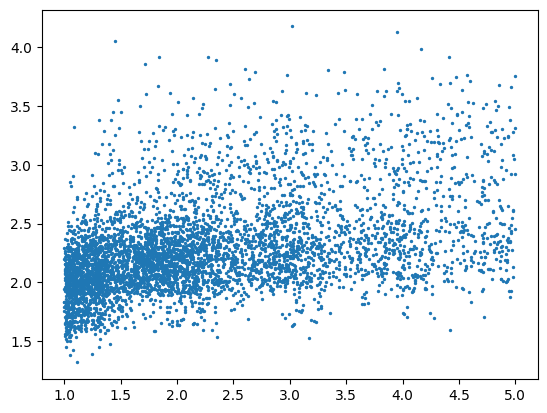

In [26]:
import matplotlib.pyplot as plt

ax = plt.scatter(Ycalibtest, Ypred, s=2)


#### reweight

In [1]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression

df_X = pd.read_csv(os.path.join('data_f', 'icu_features_transformed.csv'), index_col=0)
df_Y = pd.read_csv(os.path.join('data_f', 'icu_responses_pred.csv'), index_col=0)

In [6]:
cols = list(df_X.columns)
static_cols = []
for i in cols:
    if '_' not in i:
        static_cols.append(i)
df_X = df_X[static_cols]

In [7]:
df_X.columns

Index(['J69', 'I50', 'J98', 'N17', 'K92', 'E87', 'R09', 'Z68', 'I47', 'D64',
       ...
       'B55', 'P83', 'V10', 'N75', 'O64', 'D24', 'Age', 'gender', 'ethnicity',
       'insurance'],
      dtype='object', length=1554)

In [8]:
X, Y, f = df_X.to_numpy(), df_Y['los'].to_numpy(), df_Y['pred_los'].to_numpy()
L = (Y - f) ** 2

In [ ]:
mu = LinearRegression()
mu.fit(X, L) # error model
Lpred = mu.predict(X)

L, Lpred

(array([0.26011348, 0.75899778, 0.03414655, ..., 0.01145439, 0.01646185,
        0.12354905]),
 array([0.7785446 , 0.63891741, 0.97585731, ..., 0.36728525, 0.19100999,
        1.10948896]))

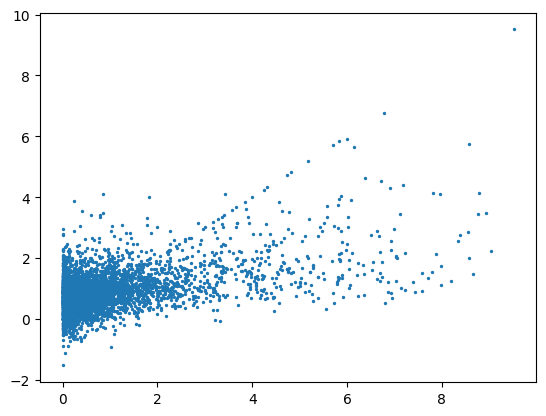

In [36]:
import matplotlib.pyplot as plt

plt.scatter(L, Lpred, s=2)
plt.show()

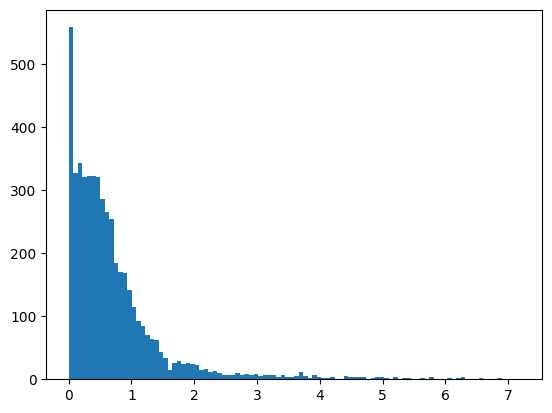

In [37]:
err = abs(L - Lpred)

plt.hist(err, bins=100)
plt.show()

In [38]:
import numpy as np

idxs = []
while len(idxs) < 5000:
    indicators = err < np.random.uniform(0, 2.5, size=len(df_Y))
    chosen_idxs = np.arange(len(df_Y))[indicators]
    idxs.extend(chosen_idxs)
idxs = idxs[:5000]

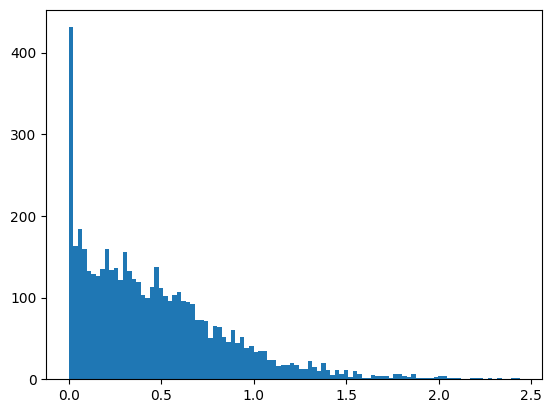

In [39]:
plt.hist(err[idxs], bins=100)
plt.show()

In [40]:
df_X_w, df_Y_w = df_X.iloc[idxs], df_Y.iloc[idxs]

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_w = df_X_w.to_numpy()
L_w = ((df_Y_w['los'] - df_Y_w['pred_los']) ** 2).to_numpy()

Xw_train, Xw_test = X_w[:2500], X_w[2500:]
Lw_train, Lw_test = L_w[:2500], L_w[2500:]

rf = RandomForestRegressor()
rf.fit(Xw_train, Lw_train)

r2_score(Lw_test, rf.predict(Xw_test))

0.3225255387533157

In [43]:
df_X_w.to_csv('icu_features_transformed_w.csv')
df_Y_w.to_csv('icu_responses_pred_w.csv')